In [1]:
import torch
from PIL import Image
import requests
from io import BytesIO
import numpy as np 
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.transforms import functional as F
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
devise = 'cuda' if torch.cuda.is_available() else device
print(f"Using device: {devise}")

Using device: mps


In [2]:
def create_segformer_mask(model, processor, product_image):
    """
    :inputs:
        model:
        processor:
        product_image:
        division:

    outputs:
    """
    masks = predict_mask(model, processor, product_image)
    masks_pixel_sums = {
        "Tops":  np.sum(masks['Tops']),
        "Bottoms": np.sum(masks['Bottoms']),
        "Dresses & Sets": np.sum(masks['Dresses & Sets']),
        }

    if masks_pixel_sums['Tops'] + masks_pixel_sums['Bottoms'] + masks_pixel_sums['Dresses & Sets'] == 0:
        return False

    biggest_garment_division = max(masks_pixel_sums, key=masks_pixel_sums.get)

    final_image = np.array(product_image) * np.stack((masks[ biggest_garment_division ],) * 3, axis=-1)
    final_dict = { biggest_garment_division : Image.fromarray( final_image.astype( np.uint8 ))}

    return final_dict

In [3]:
import torch.nn as nn
def predict_mask(model, processor, product_image):

    """
    Parameters
    ----------
    model: masking model
    processor: masking processor
    product_image: image to be maskes

    Returns
    -------
    all masks in the form of a dict
    The masks are:
    
    """

    inputs = processor(images=product_image, return_tensors="pt").to(device)
    outputs = model(**inputs)
    logits = outputs.logits

    upsampled_logits = nn.functional.interpolate(
        logits,
        size=product_image.size[::-1],
        mode="bilinear",
        align_corners=False,
    )
    predicted_mask = upsampled_logits.argmax(dim=1).squeeze().cpu().numpy()

    # TOPS
    predicted_top = predicted_mask == 4

    #BOTTOMS
    predicted_skirt = predicted_mask == 5
    predicted_pants = predicted_mask == 6
    predicted_bottoms = predicted_skirt + predicted_pants

    #DRESSES
    predicted_dress = predicted_mask == 7

    masks = {
        "Tops": predicted_top,
        "Bottoms": predicted_bottoms,
        "Dresses & Sets": predicted_dress,
        }
    return masks

In [5]:
from diffusers import StableDiffusionInpaintPipeline
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting"
).to(device)


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /Users/stell/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /Users/stell/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /Users/stell/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /Users/stell/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /Users/stell/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /Users/stell/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
mask_model = maskrcnn_resnet50_fpn(pretrained=True)
mask_model.eval()

masking_processor = SegformerImageProcessor.from_pretrained("sayeed99/segformer_b3_clothes")
masking_model = AutoModelForSemanticSegmentation.from_pretrained("sayeed99/segformer_b3_clothes")
masking_model = masking_model.to(device)

/Users/stell/Desktop/semfe_lab/semfe_lab/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/stell/Desktop/semfe_lab/semfe_lab/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading weights:   0%|          | 0/644 [00:00<?, ?it/s]

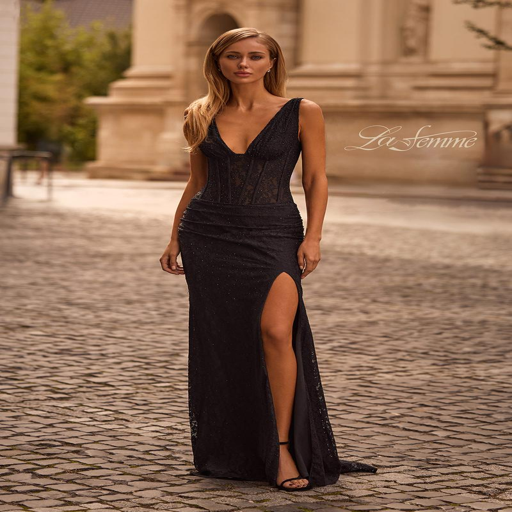

{'Dresses & Sets': <PIL.Image.Image image mode=RGB size=512x512 at 0x14D87B0D0>}


In [17]:
url = "https://www.terrycosta.com/cdn/shop/files/32943_Black_F_Editorial_810x.jpg?v=1733181803"
response = requests.get(url)
init_image = Image.open(BytesIO(response.content)).convert("RGB")
init_image = init_image.resize((512, 512))
display(init_image)
masked_images = create_segformer_mask(masking_model, masking_processor, init_image)
print(masked_images)

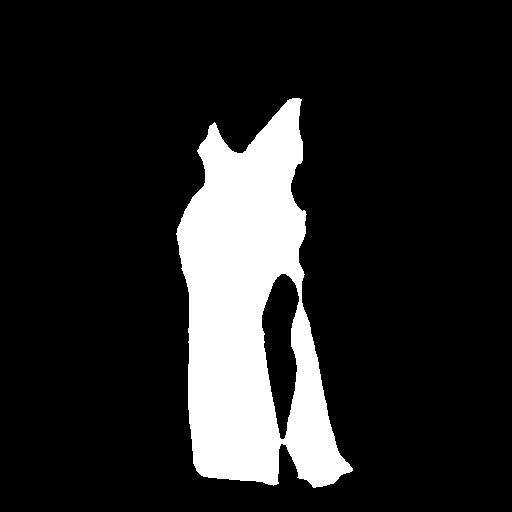

In [27]:

mask = masked_images['Dresses & Sets'].convert("L")
mask = mask.resize(init_image.size)
mask =masked_images['Dresses & Sets'].convert("L") 
mask = mask.point(lambda p: 255 if p > 1 else 0) 
display(mask)

In [28]:

edited = pipe(prompt='change the dress color to a monochrome blue dress', image=init_image, mask_image=mask).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

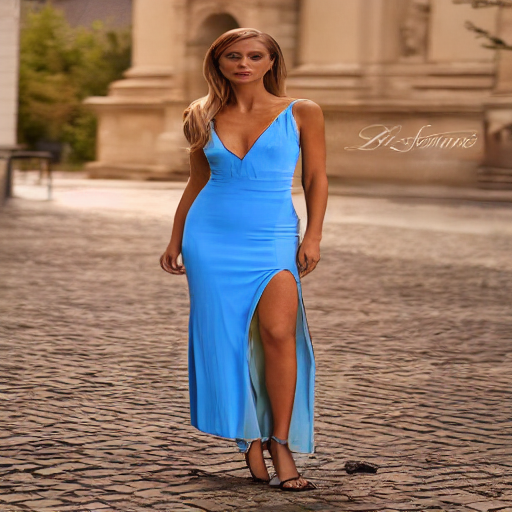

In [29]:
display(edited)